# TP 1 — métriques de classification et seuil

Le jeu de données est coupé en trois : l'**entraînement** sert à ajuster les trois modèles, la **validation** sert à choisir les réglages comme le seuil, le **test** à estimer ce qu'ils valent.

## 1.0 Trois modèles à départager

Le jeu **Breast Cancer Wisconsin** décrit 569 biopsies de masses mammaires par 30 mesures prises au microscope sur les noyaux des cellules. L'étiquette vaut 1 pour une tumeur **maligne** (le positif) et 0 pour une bénigne.

On en garde 447, dont 90 malignes seulement : la classe positive y est rare (prévalence 0,20).

Trois modèles, A, B et C, ont été entraînés sur le jeu d'entraînement. Chacun donne pour chaque biopsie un **score** entre 0 et 1, et la décision suit la règle **score ≥ seuil → « maligne »**. On les compare sur la validation, avec deux lignes de base : ToujoursBenigne et ToujoursMaligne.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, auc, precision_recall_curve,
                             average_precision_score)

plt.rcParams.update({"figure.dpi": 100, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def fr(x, n=3):
    """Number formatted with the French decimal comma, for figure labels."""
    return f"{x:.{n}f}".replace(".", ",")

WEAK = [1, 4, 8, 9]          # model A's measurements: texture, smoothness, symmetry, fractal dimension (mean)

data = load_breast_cancer()
X_all, y_all = data.data, (data.target == 0).astype(int)

rng = np.random.default_rng(0)                                # every benign biopsy, 90 malignant ones at random
malignant, benign = np.where(y_all == 1)[0], np.where(y_all == 0)[0]
keep = np.sort(np.concatenate([rng.choice(malignant, 90, replace=False), benign]))
X, y = X_all[keep], y_all[keep]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=0)

model_A = make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=5000)).fit(X_train[:, WEAK], y_train)
model_B = GaussianNB().fit(X_train, y_train)
model_C = make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=5000)).fit(X_train, y_train)

def scores_of(Xs):
    """Score of each model: how much the biopsy looks malignant, between 0 and 1."""
    return {"A": model_A.predict_proba(Xs[:, WEAK])[:, 1],
            "B": model_B.predict_proba(Xs)[:, 1],
            "C": model_C.predict_proba(Xs)[:, 1]}

s_val = scores_of(X_val)                                      # the test set stays sealed until 1.5
always_benign = np.zeros(len(y_val), dtype=int)
always_malignant = np.ones(len(y_val), dtype=int)

assert np.array_equal(model_A.predict(X_val[:, WEAK]), (s_val["A"] >= 0.5).astype(int))

## 1.1 Quatre cases pour compter les erreurs

Ces quatre cases forment la **matrice de confusion** : V/F dit si la prédiction est juste, P/N ce qu'elle annonce. Lignes = classe réelle, colonnes = classe prédite (en code : `TP`, `TN`, `FP`, `FN`).

| | prédit « bénigne » | prédit « maligne » |
|---|---|---|
| **réel « bénigne »** | VN | FP |
| **réel « maligne »** | FN | VP |

**Q1.** Une **erreur de type I** est une fausse alerte, une **erreur de type II** un cas manqué : quelle case porte chacun de ces deux noms ? Sur la validation, les bénignes sont quatre fois plus nombreuses que les malignes : suffit-il de le savoir pour prédire laquelle des deux cases d'erreur sera la plus remplie, et laquelle des deux redoutez-vous le plus ?

**Réponse attendue :** FP = type I, FN = type II. Non, cela ne suffit pas : à taux d'erreur égal dans chaque classe il y aurait bien plus de FP, puisqu'il y a quatre fois plus de bénignes sur lesquelles se tromper — mais le décompte dépend aussi de l'endroit où le modèle place son seuil, et un modèle très prudent peut n'avoir aucun FP et rien que des FN. C'est le FN qu'on redoute : un cancer manqué ne repasse pas par la case suivante, alors qu'une fausse alerte coûte une biopsie de contrôle.

Le piège : confondre « l'erreur la plus fréquente » et « l'erreur la plus grave ». Ce sont deux questions différentes, et c'est exactement ce que la justesse mélange en une seule.

In [2]:
def confusion_counts(y_true, y_pred):
    """Return (TP, TN, FP, FN) for two arrays of 0/1."""
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

for name in "ABC":
    pred = (s_val[name] >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    TP, TN, FP, FN = confusion_counts(y_val, pred)
    assert (TP, TN, FP, FN) == (tp, tn, fp, fn)
    print(f"modèle {name} au seuil 0,5 : VP = {TP}, VN = {TN}, FP = {FP}, FN = {FN}")

modèle A au seuil 0,5 : VP = 0, VN = 72, FP = 0, FN = 18
modèle B au seuil 0,5 : VP = 17, VN = 69, FP = 3, FN = 1
modèle C au seuil 0,5 : VP = 17, VN = 72, FP = 0, FN = 1


**Q2.** Traduisez en une phrase chacune des quatre cases du modèle B. Le modèle A, lui, n'a ni VP ni FP : que fait-il au seuil 0,5, et en quoi A et C démentent-ils le raisonnement sur les effectifs ?

**Réponse attendue :** VP = 17 tumeurs malignes trouvées, VN = 69 bénignes bien écartées, FP = 3 bénignes signalées à tort (type I : une biopsie de contrôle inutile), FN = 1 maligne laissée passer (type II : un cancer manqué). B se trompe plus souvent en type I (3) qu'en type II (1), et c'est pourtant ce 1 qui inquiète.

A ne prédit « maligne » sur aucune des 90 biopsies : sa matrice (VP = 0, VN = 72, FP = 0, FN = 18) est exactement celle de ToujoursBenigne. A et C démentent le décompte — 0 FP contre 18 FN, puis 0 FP contre 1 FN : les effectifs disent où il y a le plus d'occasions de se tromper, pas où le modèle a posé son seuil.

## 1.2 Une justesse élevée sans signaler une seule tumeur maligne

$$\text{justesse} = \frac{VP + VN}{VP + VN + FP + FN},\qquad \text{précision} = \frac{VP}{VP + FP},\qquad \text{rappel} = \frac{VP}{VP + FN},\qquad F_1 = \frac{2\,p\,r}{p + r}.$$

Quand $VP + FP = 0$ la précision est indéfinie : on renvoie 0.0, comme `zero_division=0` de scikit-learn (idem rappel et F1).

**Q3.** ToujoursMaligne crie « maligne » sur les 90 biopsies, dont une sur cinq l'est vraiment. Sans rien exécuter : que valent alors sa précision et son rappel, et à quoi vous attendez-vous pour leur moyenne simple et pour leur F1 — le même chiffre, ou non ?

**Réponse attendue :** Rappel = 1 (aucune maligne ne lui échappe), précision = $\pi$ = 0,20 (une alerte sur cinq est juste). La moyenne simple en fait 0,60 et flatte ; le F1, moyenne **harmonique**, est tiré vers la plus petite des deux et tombe bien plus bas : $2 \cdot 0{,}2 \cdot 1 / 1{,}2 = 0{,}333$.

Le piège : croire que « F1 = moyenne de la précision et du rappel ». C'est vrai numériquement quand les deux sont proches, et faux dès qu'elles s'écartent — c'est-à-dire exactement dans le cas qu'on veut détecter.

In [3]:
def accuracy(TP, TN, FP, FN):
    return (TP + TN) / (TP + TN + FP + FN)

def precision(TP, FP):
    return TP / (TP + FP) if TP + FP else 0.0

def recall(TP, FN):
    return TP / (TP + FN) if TP + FN else 0.0

def f1(p, r):
    return 2 * p * r / (p + r) if p + r else 0.0

predictions = {"ToujoursBenigne": always_benign, "ToujoursMaligne": always_malignant,
               "A": (s_val["A"] >= 0.5).astype(int), "B": (s_val["B"] >= 0.5).astype(int),
               "C": (s_val["C"] >= 0.5).astype(int)}
rows = []
for name, pred in predictions.items():
    TP, TN, FP, FN = confusion_counts(y_val, pred)
    p, r = precision(TP, FP), recall(TP, FN)
    assert np.isclose(accuracy(TP, TN, FP, FN), accuracy_score(y_val, pred))
    assert np.isclose(p, precision_score(y_val, pred, zero_division=0))
    assert np.isclose(r, recall_score(y_val, pred, zero_division=0))
    assert np.isclose(f1(p, r), f1_score(y_val, pred, zero_division=0))
    rows.append({"VP": TP, "VN": TN, "FP": FP, "FN": FN, "justesse": accuracy(TP, TN, FP, FN),
                 "précision": p, "rappel": r, "moy. simple": (p + r) / 2, "F1": f1(p, r)})
pd.DataFrame(rows, index=list(predictions)).round(3)

,VP,VN,FP,FN,justesse,précision,rappel,moy. simple,F1
ToujoursBenigne,0,72,0,18,0.800,0.00,0.000,0.000,0.000
ToujoursMaligne,18,0,72,0,0.200,0.20,1.000,0.600,0.333
A,0,72,0,18,0.800,0.00,0.000,0.000,0.000
B,17,69,3,1,0.956,0.85,0.944,0.897,0.895
C,17,72,0,1,0.989,1.00,0.944,0.972,0.971


**Q4.** Le modèle A a exactement la même ligne que ToujoursBenigne : que vaut sa justesse, et à quoi faut-il la comparer avant de la trouver bonne ? Le F1 de C (0,971) est collé à sa moyenne simple (0,972), celui de ToujoursMaligne (0,333) en est très loin (0,600) : à partir de quel écart entre précision et rappel la moyenne simple devient-elle trompeuse ?

**Réponse attendue :** A obtient 80,0 % sans signaler une seule tumeur maligne : c'est exactement $1 - \pi$ (72/90), la justesse de ToujoursBenigne, un modèle qui ne regarde même pas la biopsie. Une justesse ne se lit que comparée à cette ligne de base, et A ne la dépasse pas du tout. C'est le **seuil** de A qui est jugé ici, pas l'ordre de ses scores — 1.3 et 1.4 y reviennent.

Dès que précision et rappel s'écartent vraiment. C est à 1,000 contre 0,944 : son F1 (0,971) suit sa moyenne simple (0,972). ToujoursMaligne est à 0,200 contre 1,000 : son F1 (0,333) abandonne la sienne (0,600). La moyenne harmonique reste collée à la plus petite des deux, donc l'écart entre les deux moyennes mesure le déséquilibre lui-même.

Le modèle A est **volontairement** réglé très prudent (`LogisticRegression(C=0.01)` sur quatre mesures faibles) : ses scores restent écrasés près de la prévalence, d'où l'imitation de ToujoursBenigne. Ne pas le présenter comme un accident du découpage : sur 100 découpages, il ne prédit aucune maligne au seuil 0,5 dans 75 cas sur 100. Le réglage `C` contraint les poids : avec `C=1`, le même modèle prédit 14 malignes et obtient un F1 de 0,625.

## 1.3 Choisir un seuil

Le seuil 0,5 n'a rien d'obligatoire : c'est un réglage, et on le choisit sur la validation. On balaie 201 seuils entre 0 et 1 et on en retient deux pour le modèle A : `threshold_A`, celui de meilleur F1, et `threshold_90`, le cahier des charges « trouver au moins 90 % des tumeurs malignes » avec le moins de fausses alertes possible, donc le **plus grand** seuil dont le rappel atteint 0,90.

**Q5.** Vous allez monter le seuil de 0 à 1. Qu'arrive-t-il au rappel, et pourquoi ? Et à la précision : sa montée est-elle garantie, ou seulement probable ?

**Réponse attendue :** Le rappel ne peut que baisser : monter le seuil ne fait que retirer des biopsies de « prédit maligne », et son dénominateur (les vraies malignes) ne bouge pas. C'est un théorème. La précision monte *en général*, parce qu'on retire d'abord les scores les plus bas, surtout des FP — mais rien ne le garantit : son dénominateur bouge aussi, et il suffit que la biopsie qui sort soit une maligne pour que VP baisse sans que FP baisse.

Le piège : répondre « les deux sont monotones, l'un monte, l'autre descend ».

In [4]:
def precision_recall_over_thresholds(y_true, scores, thresholds):
    """Precision and recall at each threshold (rule: score >= threshold -> malignant)."""
    P, R = [], []
    for t in thresholds:
        TP, TN, FP, FN = confusion_counts(y_true, (scores >= t).astype(int))
        P.append(precision(TP, FP))
        R.append(recall(TP, FN))
    return np.array(P), np.array(R)

thresholds = np.linspace(0, 1, 201)
P_A, R_A = precision_recall_over_thresholds(y_val, s_val["A"], thresholds)
F1_A = np.array([f1(p, r) for p, r in zip(P_A, R_A)])
threshold_A = thresholds[np.argmax(F1_A)]
threshold_90 = thresholds[R_A >= 0.90].max()

assert np.allclose(P_A, [precision_score(y_val, (s_val["A"] >= t).astype(int), zero_division=0) for t in thresholds])
assert np.allclose(F1_A, [f1_score(y_val, (s_val["A"] >= t).astype(int), zero_division=0) for t in thresholds])
assert np.isclose(f1_score(y_val, (s_val["A"] >= threshold_A).astype(int), zero_division=0), F1_A.max())
assert recall_score(y_val, (s_val["A"] >= threshold_90).astype(int)) >= 0.90
assert recall_score(y_val, (s_val["A"] >= threshold_90 + 0.005).astype(int)) < 0.90
for name, t in [("seuil_A", threshold_A), ("seuil_90", threshold_90)]:
    TP, TN, FP, FN = confusion_counts(y_val, (s_val["A"] >= t).astype(int))
    p, r = precision(TP, FP), recall(TP, FN)
    print(f"{name} = {t:.3f} : VP = {TP}, FP = {FP}, FN = {FN}, "
          f"précision = {p:.3f}, rappel = {r:.3f}, F1 = {f1(p, r):.3f}")

i_A = int(np.argmin(np.abs(thresholds - threshold_A)))
rows = []
for i in [i_A, i_A + 1]:
    TP, TN, FP, FN = confusion_counts(y_val, (s_val["A"] >= thresholds[i]).astype(int))
    rows.append({"seuil": thresholds[i], "VP": TP, "VN": TN, "FP": FP, "FN": FN,
                 "précision": P_A[i], "rappel": R_A[i]})
print(f"\nprécision en baisse en {int(np.sum(np.diff(P_A) < 0))} endroits de la grille, dont seuil_A :")
print(pd.DataFrame(rows).set_index("seuil").round(3))

seuil_A = 0.235 : VP = 13, FP = 13, FN = 5, précision = 0.500, rappel = 0.722, F1 = 0.591
seuil_90 = 0.170 : VP = 17, FP = 34, FN = 1, précision = 0.333, rappel = 0.944, F1 = 0.493

précision en baisse en 10 endroits de la grille, dont seuil_A :
       VP  VN  FP  FN  précision  rappel
seuil                                   
0.235  13  59  13   5       0.50   0.722
0.240  12  59  13   6       0.48   0.667


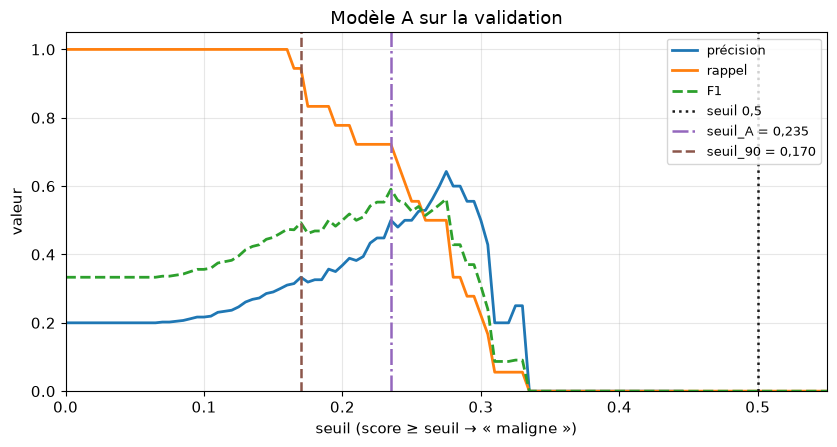

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
defined = thresholds <= s_val["A"].max()
ax.plot(thresholds[defined], P_A[defined], lw=2, label="précision")
ax.plot(thresholds, R_A, lw=2, label="rappel")
ax.plot(thresholds, F1_A, lw=2, ls="--", label="F1")
for t, label, color, style in [(0.5, "seuil 0,5", "0.1", ":"),
                               (threshold_A, f"seuil_A = {fr(threshold_A)}", "C4", "-."),
                               (threshold_90, f"seuil_90 = {fr(threshold_90)}", "C5", "--")]:
    ax.axvline(t, color=color, ls=style, lw=1.8, label=label)
ax.set_xlim(0, 0.55); ax.set_ylim(0, 1.05)
ax.set_xlabel("seuil (score ≥ seuil → « maligne »)"); ax.set_ylabel("valeur")
ax.set_title("Modèle A sur la validation")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

**Q6.** La précision baisse en plusieurs endroits de la grille, dont juste après seuil_A : une biopsie de quelle classe a changé de case entre ces deux seuils, et comment VP et FP le montrent-ils ? seuil_A et seuil_90 lisent le même modèle, avec le même ordre de scores : lequel pour un dépistage suivi d'un second examen, lequel si chaque alerte déclenche une intervention lourde ?

**Réponse attendue :** Une **maligne**. Entre 0,235 et 0,240, une tumeur maligne dont le score tombe dans cet intervalle passe dans « bénigne » : VP tombe de 13 à 12 alors que FP reste à 13, d'où 13/26 = 0,500 puis 12/25 = 0,480. Retirer un VP sans retirer de FP fait baisser la précision — c'est le cas en 10 endroits de la grille.

seuil_A = 0,235 trouve 13 malignes sur 18 (rappel 0,722) avec une alerte juste sur deux (précision 0,500), F1 0,591 ; seuil_90 = 0,170 en trouve 17 sur 18 (rappel 0,944) au prix de 34 fausses alertes (précision 0,333). Dépistage suivi d'un second examen → seuil_90 : le FN est un cancer manqué, et le second examen trie les fausses alertes. Intervention lourde à chaque alerte → seuil_A : c'est le FP qui coûte. Même modèle, même ordre des scores, seul le seuil change.

## 1.4 La courbe ROC

### (a) Une courbe pour tous les seuils

La courbe ROC trace, pour **tous** les seuils, le taux de vrais positifs $\text{TVP} = VP/(VP + FN)$ (le rappel) en fonction du taux de faux positifs $\text{TFP} = FP/(FP + VN)$. Son aire (AUC) vaut 1 pour un classement parfait, 0,5 pour le hasard.

### (b) Dix fois, cent fois plus de biopsies bénignes

Et si les bénignes étaient 10 ou 100 fois plus nombreuses, comme dans une vraie population de dépistage ? `repeat_negatives` garde les malignes et recopie k fois chaque bénigne : seule la prévalence change. Le modèle A est lu à votre `threshold_A`. La **courbe PR** porte la précision en fonction du rappel, un point par seuil, et l'**AP** (précision moyenne) la résume en un chiffre, comme l'AUC résume la ROC.

**Q7.** Au seuil 0,5, A ne signale aucune tumeur maligne. Quelle AUC lui prédisez-vous : autour de 0,5, ou nettement plus ? Et si l'on recopiait chaque bénigne 100 fois sans toucher aux modèles, que deviendraient son AUC et sa précision ?

**Réponse attendue :** Nettement plus que 0,5 : l'AUC ne juge pas les décisions mais l'**ordre** des scores, et A peut très bien placer les malignes devant les bénignes tout en étant trop prudent pour franchir 0,5. Quand on recopie les bénignes, les deux taux de la ROC ont leur dénominateur dans une seule classe (TVP sur les malignes, TFP sur les bénignes) : ils ne bougent pas, l'AUC non plus. La précision, elle, mélange les deux classes au dénominateur — FP est multiplié par k, VP non — elle s'effondre.

Le piège : croire qu'un modèle « qui ne prédit rien » a une AUC de 0,5, et croire qu'une bonne AUC protège d'une précision misérable.

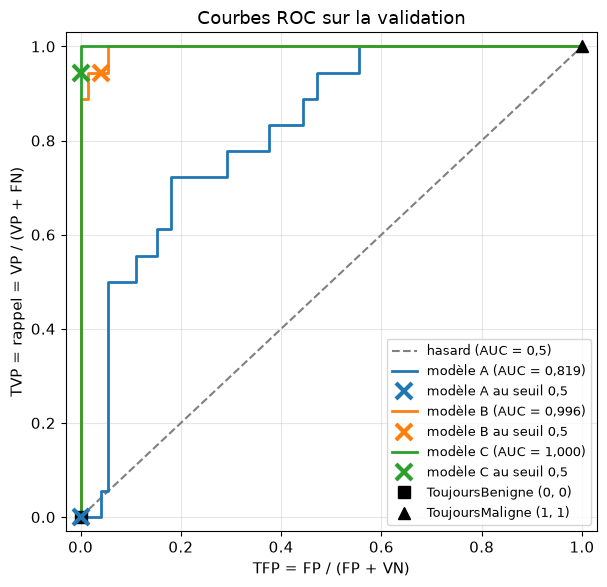

In [6]:
def roc_points(y_true, scores):
    """ROC points (FPR, TPR), one per threshold, from the smallest score to +inf."""
    thresholds = np.append(np.unique(scores), np.inf)
    fpr, tpr = [], []
    for t in thresholds:
        TP, TN, FP, FN = confusion_counts(y_true, (scores >= t).astype(int))
        tpr.append(TP / (TP + FN))
        fpr.append(FP / (FP + TN))
    return np.array(fpr), np.array(tpr)

for name in "ABC":
    assert np.isclose(auc(*roc_points(y_val, s_val[name])), roc_auc_score(y_val, s_val[name]))

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="hasard (AUC = 0,5)")
for i, name in enumerate("ABC"):
    fpr, tpr = roc_points(y_val, s_val[name])
    ax.plot(fpr, tpr, lw=2, color=f"C{i}", label=f"modèle {name} (AUC = {fr(auc(fpr, tpr))})")
    TP, TN, FP, FN = confusion_counts(y_val, (s_val[name] >= 0.5).astype(int))
    ax.plot(FP / (FP + TN), TP / (TP + FN), "x", color=f"C{i}", ms=12, mew=3, zorder=5,
            label=f"modèle {name} au seuil 0,5")
ax.plot(0, 0, "ks", ms=9, label="ToujoursBenigne (0, 0)")
ax.plot(1, 1, "k^", ms=9, label="ToujoursMaligne (1, 1)")
ax.set_xlabel("TFP = FP / (FP + VN)"); ax.set_ylabel("TVP = rappel = VP / (VP + FN)")
ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
ax.set_title("Courbes ROC sur la validation")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

        m  prévalence     AUC  VP    FP    VN     TVP     TFP  précision  \
k                                                                          
1      90      0.2000  0.8194  13    13    59  0.7222  0.1806     0.5000   
10    738      0.0244  0.8194  13   130   590  0.7222  0.1806     0.0909   
100  7218      0.0025  0.8194  13  1300  5900  0.7222  0.1806     0.0099   

     justesse A  justesse ToujoursBenigne  
k                                          
1        0.8000                    0.8000  
10       0.8171                    0.9756  
100      0.8192                    0.9975  


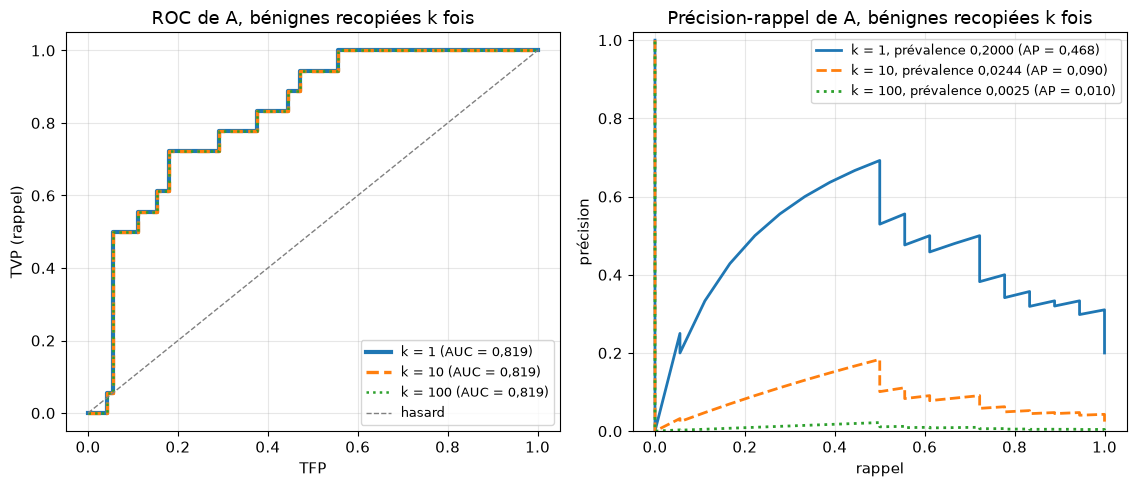

In [7]:
def repeat_negatives(y_true, scores, k):
    """Keep the positives and repeat every negative k times: only the prevalence changes."""
    pos, neg = scores[y_true == 1], scores[y_true == 0]
    return (np.concatenate([np.ones(len(pos), dtype=int), np.zeros(k * len(neg), dtype=int)]),
            np.concatenate([pos, np.tile(neg, k)]))

rows = []
for k in [1, 10, 100]:
    y_k, s_k = repeat_negatives(y_val, s_val["A"], k)
    TP, TN, FP, FN = confusion_counts(y_k, (s_k >= threshold_A).astype(int))
    assert np.allclose(roc_points(y_k, s_k), roc_points(y_val, s_val["A"]))
    rows.append({"k": k, "m": len(y_k), "prévalence": y_k.mean(), "AUC": auc(*roc_points(y_k, s_k)),
                 "VP": TP, "FP": FP, "VN": TN, "TVP": TP / (TP + FN), "TFP": FP / (FP + TN),
                 "précision": precision(TP, FP), "justesse A": accuracy(TP, TN, FP, FN),
                 "justesse ToujoursBenigne": 1 - y_k.mean()})
print(pd.DataFrame(rows).set_index("k").round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))
for i, k in enumerate([1, 10, 100]):
    y_k, s_k = repeat_negatives(y_val, s_val["A"], k)
    fpr, tpr, _ = roc_curve(y_k, s_k)
    ax1.plot(fpr, tpr, ls=["-", "--", ":"][i], lw=3 - 0.6 * i, color=f"C{i}",
             label=f"k = {k} (AUC = {fr(roc_auc_score(y_k, s_k))})")
    prec, rec, _ = precision_recall_curve(y_k, s_k)
    ax2.plot(rec, prec, ls=["-", "--", ":"][i], lw=2, color=f"C{i}",
             label=f"k = {k}, prévalence {fr(y_k.mean(), 4)} (AP = {fr(average_precision_score(y_k, s_k))})")
ax1.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="hasard")
ax1.set_xlabel("TFP"); ax1.set_ylabel("TVP (rappel)"); ax1.set_title("ROC de A, bénignes recopiées k fois")
ax1.legend(loc="lower right", fontsize=9)
ax2.set_xlabel("rappel"); ax2.set_ylabel("précision"); ax2.set_ylim(0, 1.02)
ax2.set_title("Précision-rappel de A, bénignes recopiées k fois")
ax2.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

**Q8.** Sur la première figure, la croix de A est en (0, 0) alors que sa courbe passe bien au-dessus de la diagonale : que dit chacune des deux ? À k = 10, ToujoursBenigne dépasse A en justesse : A est-il devenu pire, et quelle courbe présenter pour une classe rare ?

**Réponse attendue :** La croix en (0, 0) est la décision au seuil 0,5 — ni VP ni FP, le coin « je ne signale rien ». La courbe décrit tous les autres seuils : AUC 0,819, l'ordre des scores vaut quelque chose.

À k = 10 puis 100, A n'a pas changé : même TVP 0,722, même TFP 0,181, même AUC 0,819 — c'est la tâche qui a changé. Sa précision, elle, vaut $13/(13 + 13k)$ : 0,500 → 0,0909 → 0,0099, et l'AP suit (0,468 → 0,090 → 0,010). La justesse ne voit rien de cette chute : elle récompense ToujoursBenigne (0,976 contre 0,817), qui ne trouve toujours aucune tumeur maligne. Pour une classe rare on présente la courbe PR, ou la précision à la prévalence réelle : la ROC ne voit pas la rareté, la précision la subit.

## 1.5 Le test ne s'utilise qu'une fois

Les réglages sont choisis : on utilise le test (90 biopsies, dont 18 malignes) une seule fois, pour estimer ce qu'ils valent.

**Q9.** seuil_90 a été réglé sur la validation pour y atteindre 90 % de rappel. Sur le test, attendez-vous un rappel au-dessus, en dessous, ou exactement aux 90 % promis ? Et de combien un seul cas manqué peut-il déplacer ce rappel ?

**Réponse attendue :** En dessous, en moyenne : le seuil a été choisi comme le plus grand qui atteint 0,90 *sur les 18 malignes de la validation*, il épouse ces 18 cas-là, donc le chiffre de validation est optimiste. Sur 18 nouvelles malignes, une seule vaut 1/18 = 5,6 points de rappel : l'écart peut être brutal sans que rien ne soit cassé.

Le piège : conclure d'un rappel de test sous 0,90 que le code est faux, alors que c'est le comportement attendu de tout réglage choisi sur un autre jeu.

In [8]:
s_test = scores_of(X_test)
rows = []
for label, model, t in [(f"A au seuil_A ({threshold_A:.3f})", "A", threshold_A),
                        (f"A au seuil_90 ({threshold_90:.3f})", "A", threshold_90),
                        ("C au seuil 0,5", "C", 0.5)]:
    for split, y_split, scores in [("validation", y_val, s_val), ("test", y_test, s_test)]:
        TP, TN, FP, FN = confusion_counts(y_split, (scores[model] >= t).astype(int))
        p, r = precision(TP, FP), recall(TP, FN)
        rows.append({"cas": label, "jeu": split, "VP": TP, "VN": TN, "FP": FP, "FN": FN,
                     "justesse": accuracy(TP, TN, FP, FN), "précision": p, "rappel": r, "F1": f1(p, r),
                     "AUC": roc_auc_score(y_split, scores[model])})
print(f"ToujoursBenigne sur le test : justesse {1 - y_test.mean():.3f}\n")
pd.DataFrame(rows).set_index(["cas", "jeu"]).round(3)

ToujoursBenigne sur le test : justesse 0.800



VP  VN  FP  FN  justesse  précision  rappel  \
cas                   jeu                                                       
A au seuil_A (0.235)  validation  13  59  13   5     0.800      0.500   0.722   
                      test        10  58  14   8     0.756      0.417   0.556   
A au seuil_90 (0.170) validation  17  38  34   1     0.611      0.333   0.944   
                      test        15  32  40   3     0.522      0.273   0.833   
C au seuil 0,5        validation  17  72   0   1     0.989      1.000   0.944   
                      test        12  72   0   6     0.933      1.000   0.667   

                                     F1    AUC  
cas                   jeu                       
A au seuil_A (0.235)  validation  0.591  0.819  
                      test        0.476  0.769  
A au seuil_90 (0.170) validation  0.493  0.819  
                      test        0.411  0.769  
C au seuil 0,5        validation  0.971  1.000  
                      test        0.800  0.988

**Q10.** Le rappel promis est-il tenu ? Quel chiffre annonce-t-on alors dans un rapport, et que dit par ailleurs la ligne de C ?

**Réponse attendue :** Non, il tombe à 0,833 (15 malignes sur 18) contre 0,944 en validation. L'`assert` de 1.3 le disait déjà : 0,005 de seuil en plus et le rappel de validation lui-même passait sous 0,90 — seuil_90 était collé au bord. On annonce le chiffre du **test**, mesuré une seule fois, jamais celui qui a servi à choisir.

La ligne de C le confirme sur le meilleur modèle : AUC 1,000 et rappel 0,944 en validation, mais 0,667 au test (6 malignes manquées sur 18, justesse 0,933) — le test dégrise tout le monde.

Deux chiffres de ce tableau sont propres à ce découpage, à présenter comme tels. Sur 100 découpages, le rappel de test à seuil_90 vaut 0,904 en moyenne contre 0,952 en validation, et il passe sous 0,90 dans 47 % des cas seulement : c'est une tendance en moyenne, pas une loi à chaque découpage (dans un tiers des découpages les deux rappels sont égaux, une seule maligne valant 5,6 points). Et C, dont les scores séparent parfaitement la validation (AUC 1,000 ; plus grand score bénin 0,331, plus petit score malin 0,349), manque 6 malignes sur 18 sur le test : le test dégrise aussi le meilleur modèle.